In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter
land = cfeature.NaturalEarthFeature(category='physical', name='land',
                                    scale='50m',
                                    facecolor=cfeature.COLORS['land'])
ocean = cfeature.NaturalEarthFeature(category='physical', name='ocean',
                                     scale='50m',
                                     facecolor=cfeature.COLORS['water'])

In [ ]:
# Load IB data
dfib = pd.read_csv("../IB_track_file/IBTrACS_TC_Size.csv",keep_default_na=False)
dfib['ISOTIME'] = pd.to_datetime(dfib['ISOTIME'])
dfib_track=pd.read_csv("../IB_track_file/ibtracs_ERA5_track_pair.csv",keep_default_na=False) # IB track type info
ib_et_id=dfib_track[dfib_track.end_type=='ET'].TID.values
ib_land_id=dfib_track[dfib_track.end_type=='LAND'].TID.values

In [ ]:
# Preprocess IB data
dfib_all=dfib.copy()
dfib_all['index']=np.arange(0,len(dfib_all),1)
fst=dfib_all.groupby('TID')['index'].first()
dfib_all['lapse']=dfib_all.groupby(['TID'],group_keys=False)['index'].apply(lambda x: x-list(x)[0])
dfib_all['MSLP']=np.where(dfib_all['MSLP']==0, dfib_all['WMO_PRES'], dfib_all['MSLP'])
# Remove a few TCs that originated in the EP and moved into the WNP
epid=dfib_all[(dfib_all['lapse']==0) & (dfib_all.MSLP<990) & (dfib_all.LON>176)].TID.unique()
dfib_all=dfib_all[~dfib_all['TID'].isin(epid)].reset_index(drop=True)

In [ ]:
# Assign track types by basin
wp_ms_et_id=dfib_track[(dfib_track.end_type=='ET') & (dfib_track.begin_type=='MS') & (dfib_track.basin_label=='WP')].TID.values
wp_ms_land_id=dfib_track[(dfib_track.end_type=='LAND') & (dfib_track.begin_type=='MS') & (dfib_track.basin_label=='WP')].TID.values
wp_ms_net_id=dfib_track[(dfib_track.end_type=='Non-ET') & (dfib_track.begin_type=='MS') & (dfib_track.basin_label=='WP')].TID.values
wp_nms_et_id=dfib_track[(dfib_track.end_type=='ET') & (dfib_track.begin_type=='Non-MS') & (dfib_track.basin_label=='WP')].TID.values
wp_nms_land_id=dfib_track[(dfib_track.end_type=='LAND') & (dfib_track.begin_type=='Non-MS') & (dfib_track.basin_label=='WP')].TID.values
wp_nms_net_id=dfib_track[(dfib_track.end_type=='Non-ET') & (dfib_track.begin_type=='Non-MS') & (dfib_track.basin_label=='WP')].TID.values
wp_tt_id=dfib_track[(dfib_track.begin_type=='TT') & (dfib_track.basin_label=='WP')].TID.values
wp_id=dfib_track[(dfib_track.basin_label=='WP')].TID.values

na_ms_id=dfib_track[(dfib_track.begin_type=='MS') & (dfib_track.basin_label=='NA')].TID.values
na_nms_et_id=dfib_track[(dfib_track.end_type=='ET') & (dfib_track.begin_type=='Non-MS') & (dfib_track.basin_label=='NA')].TID.values
na_nms_land_id=dfib_track[(dfib_track.end_type=='LAND') & (dfib_track.begin_type=='Non-MS') & (dfib_track.basin_label=='NA')].TID.values
na_nms_net_id=dfib_track[(dfib_track.end_type=='Non-ET') & (dfib_track.begin_type=='Non-MS') & (dfib_track.basin_label=='NA')].TID.values
na_tt_id=dfib_track[(dfib_track.begin_type=='TT') & (dfib_track.basin_label=='NA')].TID.values
na_id=dfib_track[(dfib_track.basin_label=='NA')].TID.values


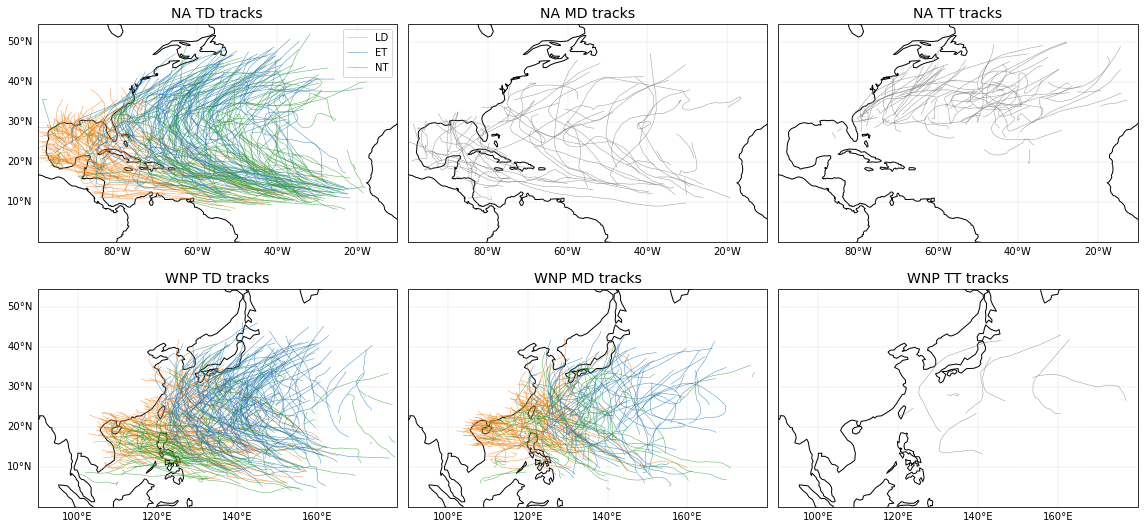

In [ ]:
# Plot figure 1
fig = plt.figure(figsize=(16,8),layout="tight")

ax1 = fig.add_subplot(2,3,1,projection=ccrs.PlateCarree(central_longitude=0))
na_track_list=[na_nms_land_id, na_nms_et_id, na_nms_net_id]
color_lst=['tab:orange','tab:blue','tab:green']
legend_lst=['LD','ET','NT']
count=0
for track_list in na_track_list:
    df0=dfib_all[dfib_all.TID.isin(track_list)]
    LAT1 = df0.groupby('TID')['LAT'].apply(list)
    LON1 = df0.groupby('TID')['LON'].apply(list)
    for i in range(len(LON1)):
        if i==0:
             ax1.plot(LON1.iloc[i],LAT1.iloc[i], transform=ccrs.Geodetic(), linestyle='-',linewidth=0.5,c=color_lst[count],alpha=0.8,label=legend_lst[count])
        else:
            ax1.plot(LON1.iloc[i],LAT1.iloc[i], transform=ccrs.Geodetic(), linestyle='-',linewidth=0.5,c=color_lst[count],alpha=0.8)
    count+=1
gl = ax1.gridlines(draw_labels=True,xformatter=LongitudeFormatter(zero_direction_label=True),linewidth=0.3, color='gray', linestyle='dotted')
gl.top_labels = False;gl.right_labels = False
# ax1.add_feature(land)
# ax1.add_feature(ocean)
ax1.coastlines(color='k')
ax1.set_extent([-100, -10, 0, 45])
ax1.set_title('NA TD tracks', fontsize=14)
ax1.legend(fontsize=10,loc='upper right')

ax1 = fig.add_subplot(2,3,2,projection=ccrs.PlateCarree(central_longitude=0))
na_track_list=[na_ms_id]
for track_list in na_track_list:
    df0=dfib_all[dfib_all.TID.isin(track_list)]
    LAT1 = df0.groupby('TID')['LAT'].apply(list)
    LON1 = df0.groupby('TID')['LON'].apply(list)
    for i in range(len(LON1)):
        ax1.plot(LON1.iloc[i],LAT1.iloc[i], transform=ccrs.Geodetic(), linestyle='-',linewidth=0.5,c='gray',alpha=0.8)
gl = ax1.gridlines(draw_labels=True,xformatter=LongitudeFormatter(zero_direction_label=True),linewidth=0.3, color='gray', linestyle='dotted')
gl.top_labels = False;gl.right_labels = False; gl.left_labels = False
# ax1.add_feature(land)
# ax1.add_feature(ocean)
ax1.coastlines(color='k')
ax1.set_extent([-100, -10, 0, 45])
ax1.set_title('NA MD tracks', fontsize=14)

ax1 = fig.add_subplot(2,3,3,projection=ccrs.PlateCarree(central_longitude=0))
na_track_list=[na_tt_id]
for track_list in na_track_list:
    df0=dfib_all[dfib_all.TID.isin(track_list)]
    LAT1 = df0.groupby('TID')['LAT'].apply(list)
    LON1 = df0.groupby('TID')['LON'].apply(list)
    for i in range(len(LON1)):
        ax1.plot(LON1.iloc[i],LAT1.iloc[i], transform=ccrs.Geodetic(), linestyle='-',linewidth=0.5,c='grey',alpha=0.8)
gl = ax1.gridlines(draw_labels=True,xformatter=LongitudeFormatter(zero_direction_label=True),linewidth=0.3, color='gray', linestyle='dotted')
gl.top_labels = False;gl.right_labels = False; gl.left_labels = False
# ax1.add_feature(land)
# ax1.add_feature(ocean)
ax1.coastlines(color='k')
ax1.set_extent([-100, -10, 0, 45])
ax1.set_title('NA TT tracks', fontsize=14)

ax1 = fig.add_subplot(2,3,4,projection=ccrs.PlateCarree(central_longitude=180))
wp_track_list=[wp_nms_land_id, wp_nms_et_id, wp_nms_net_id]
color_lst=['tab:orange','tab:blue','tab:green']
count=0
for track_list in wp_track_list:
    df0=dfib_all[dfib_all.TID.isin(track_list)]
    LAT1 = df0.groupby('TID')['LAT'].apply(list)
    LON1 = df0.groupby('TID')['LON'].apply(list)
    for i in range(len(LON1)):
        ax1.plot(LON1.iloc[i],LAT1.iloc[i], transform=ccrs.Geodetic(), linestyle='-',linewidth=0.5,c=color_lst[count],alpha=0.8)
    count+=1
gl = ax1.gridlines(draw_labels=True,xformatter=LongitudeFormatter(zero_direction_label=True),linewidth=0.3, color='gray', linestyle='dotted')
gl.top_labels = False;gl.right_labels = False
# ax1.add_feature(land)
# ax1.add_feature(ocean)
ax1.coastlines(color='k')
ax1.set_extent([90, 180, 0, 45])
ax1.set_title('WNP TD tracks', fontsize=14)

ax1 = fig.add_subplot(2,3,5,projection=ccrs.PlateCarree(central_longitude=180))
wp_track_list=[wp_ms_land_id, wp_ms_et_id, wp_ms_net_id]
color_lst=['tab:orange','tab:blue','tab:green']
count=0
for track_list in wp_track_list:
    df0=dfib_all[dfib_all.TID.isin(track_list)]
    LAT1 = df0.groupby('TID')['LAT'].apply(list)
    LON1 = df0.groupby('TID')['LON'].apply(list)
    for i in range(len(LON1)):
        ax1.plot(LON1.iloc[i],LAT1.iloc[i], transform=ccrs.Geodetic(), linestyle='-',linewidth=0.5,c=color_lst[count],alpha=0.8)
    count+=1
gl = ax1.gridlines(draw_labels=True,xformatter=LongitudeFormatter(zero_direction_label=True),linewidth=0.3, color='gray', linestyle='dotted')
gl.top_labels = False;gl.right_labels = False; gl.left_labels = False
# ax1.add_feature(land)
# ax1.add_feature(ocean)
ax1.coastlines(color='k')
ax1.set_extent([90, 180, 0, 45])
ax1.set_title('WNP MD tracks', fontsize=14)

ax1 = fig.add_subplot(2,3,6,projection=ccrs.PlateCarree(central_longitude=180))
wp_track_list=[wp_tt_id]
for track_list in wp_track_list:
    df0=dfib_all[dfib_all.TID.isin(track_list)]
    LAT1 = df0.groupby('TID')['LAT'].apply(list)
    LON1 = df0.groupby('TID')['LON'].apply(list)
    for i in range(len(LON1)):
        ax1.plot(LON1.iloc[i],LAT1.iloc[i], transform=ccrs.Geodetic(), linestyle='-',linewidth=0.5,c='gray',alpha=0.8)
gl = ax1.gridlines(draw_labels=True,xformatter=LongitudeFormatter(zero_direction_label=True),linewidth=0.3, color='gray', linestyle='dotted')
gl.top_labels = False;gl.right_labels = False; gl.left_labels = False
# ax1.add_feature(land)
# ax1.add_feature(ocean)
ax1.coastlines(color='k')
ax1.set_extent([90, 180, 0, 45])
ax1.set_title('WNP TT tracks', fontsize=14)

plt.savefig('../figures/figure1.jpg',dpi=500)

